# Constructed Scene Generation

Builds the two-instance scenes the spatial-language measurement requires, by
compositing rather than by filtering.

A spatial term is the sole disambiguator only when a scene holds two instances
of the same object, so that "the cup on the left" and "the cup on the right"
each name a distinct, real target. In any other scene the model can reach the
correct object by finding the only one present, and the trial measures object
detection rather than spatial language. BridgeData V2 rarely contains such a
scene: manual review of a cache of a few thousand frames found the qualifying set
to be in single figures, and filtering can only discard scenes, never create the
ones the measurement needs.

Each constructed scene takes a real frame holding one confident instance of the
target noun, cuts that instance from its own pixels, mirrors it, and pastes it
at a chosen position. The camera pose, lighting, and background stay real, while
the arrangement becomes known because it was chosen. The expected direction for
every trial therefore comes from recorded geometry rather than from the wording
of the instruction.

Three configurations are produced. `opposite` places one instance either side of
the start position of the end effector, the classic well-posed trial. `same_side_left` and
`same_side_right` place both instances on one side. A model that grounds the
term keeps one sign for both instructions, while a
fixed word-to-direction mapping produces opposite signs. That contrast is what
separates the two accounts, and it cannot be sampled from found data at all.

The notebook runs to a fixed set, in four stages.

1. **Build**, to a per-configuration target with an overbuild factor, since some
   scenes will fail the screen. The manifest is appended as scenes are
   produced and a later run skips the base frames it already covers.
2. **Screen.** Every scene is looked at once against criteria fixed in advance,
   and a failure is recorded with its reason. This is stimulus quality, not
   selection on the result. This
   removes are composites where the duplicate does not read as a second object of
   the named kind, so the instruction has no second referent and the trial measures
   nothing.
3. **Freeze.** The screened scenes are selected into a fixed list, paired so that
   each same-side scene sits alongside the opposite scene from its own base frame.
   Every later stage reads that list, so the set cannot drift as screening
   continues.
4. **Measure agreement** on a random subsample, giving the recorded geometry a
   reportable number rather than an assumption.

No OpenVLA load is needed. The notebook runs the open-vocabulary detector only,
so a CPU or a small GPU runtime is sufficient.

## 1. Mount Drive

Drive holds the harvested frames, the constructed-set outputs, and the Hugging
Face cache for OpenVLA. `HF_HOME` is pointed at that cache so a later session
that loads the 7B weights does not download them again. OWLv2 and SAM, which
this notebook does load, are kept on the runtime disk instead: Drive's FUSE
mount cannot create the hub snapshot symlink, and the fallback copy of the
weights file fails with an I/O error.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.environ['HF_HOME'] = '/content/drive/MyDrive/openvla_cache/hf'
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/v2/bridge'
CONSTRUCTED_DIR = '/content/drive/MyDrive/openvla_cache/v2/constructed'
assert os.path.isfile(os.path.join(CACHE_DIR, 'manifest.csv')), (
    f'No manifest at {CACHE_DIR}; run the harvest in Notebook 02 first.'
)
os.makedirs(CONSTRUCTED_DIR, exist_ok=True)
print('cache       ->', CACHE_DIR)
print('constructed ->', CONSTRUCTED_DIR)

Mounted at /content/drive
cache       -> /content/drive/MyDrive/openvla_cache/v2/bridge
constructed -> /content/drive/MyDrive/openvla_cache/v2/constructed


## 2. Import the code

Clones the project code from GitHub into the runtime and imports the
construction and detection functions from there, so the code always matches the
pushed commit.

In [2]:
import sys, os, importlib, subprocess

REPO_URL = 'https://github.com/LewisTL/ECS8056.git'
BRANCH = 'master'
REPO_DIR = '/content/ECS8056'

def sync_repo():
    """Clone or hard-refresh the repository so it matches origin/BRANCH."""
    token = os.environ.get('GITHUB_TOKEN', '')
    url = REPO_URL.replace('https://', f'https://{token}@') if token else REPO_URL
    if os.path.isdir(os.path.join(REPO_DIR, '.git')):
        subprocess.run(['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', url],
                       check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'fetch', '--quiet', '--depth', '1',
                        'origin', BRANCH], check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', '--quiet',
                        f'origin/{BRANCH}'], check=True)
    else:
        subprocess.run(['git', 'clone', '--quiet', '--depth', '1', '--branch',
                        BRANCH, url, REPO_DIR], check=True)
    return subprocess.run(['git', '-C', REPO_DIR, 'rev-parse', '--short', 'HEAD'],
                          capture_output=True, text=True).stdout.strip()


commit = sync_repo()
module_dir = REPO_DIR
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
for _m in ('data', 'detect_duplicates', 'compose_scenes',):
    sys.modules.pop(_m, None)
importlib.invalidate_caches()

import compose_scenes
from compose_scenes import (run_construction, load_constructed_manifest,
                            select_base_scenes, locate_gripper, CONFIGURATIONS,
                            diagnose_detection, summarise_diagnosis,
                            MODE_INHERITED, MODE_SYNTHESISED,
                            SINGLE_HIGH, SINGLE_SECOND_MAX,
                            DEFAULT_TARGETS, DECISION_APPROVED, DECISION_REJECTED,
                            REJECT_REASONS, approval_summary, approve,
                            approved_ids, evaluation_scenes, load_review,
                            pair_eligible_ids, project_yield,
                            select_evaluation_set, sync_review,
                            write_evaluation_set, write_review)
from data import SPLIT_CONSTRUCTION, load_manifest
print(f'imported project modules from {module_dir} @ {commit}')

imported project modules from /content/ECS8056 @ 021d1dc


## 3. Eligible base frames

Two modes decide where a trial's instruction comes from, and they differ 
in how many frames qualify.

`inherited` uses the episode's own instruction, which must already contain a
lateral term in a referent-selection frame. Placement instructions cannot be used,
there the spatial term governs the landmark rather than the object being moved
("move the pot to the right of the spoon"), so duplicating the moved object gives
two pots while the swapped term still names a destination beside the spoon, and the
term does not choose between the two instances. That restriction leaves a very
small pool.

`synthesised` writes the instruction over the episode's manipulated object, so any
construction frame with a nameable, liftable object qualifies. Besides enlarging the
pool to the whole construction role, holding the wording fixed across every trial
removes
instruction form as a nuisance variable. Under inherited wording, a difference
between two scenes could always be attributed to their differing phrasing rather
than to their geometry. The cost is external validity, since the instructions are
no longer verbatim from the source data, and the unmodified Bridge scenes carry
that burden instead. `instruction_source` records which mode produced each scene.

Nouns naming fixtures are refused in synthesised mode. "pick up the microwave on
the left" is unsatisfiable whatever the arrangement, and non-compliance with it
would say nothing about spatial grounding, which is the confound the constructed
set exists to remove.

Both counts are taken over the construction role only, since the validation frames
are held back unaltered and are never composited.

The counts below are what decide which mode to use.

In [3]:
from collections import Counter

manifest_rows = load_manifest(CACHE_DIR)
construction_pool = [r for r in manifest_rows if r['split'] == SPLIT_CONSTRUCTION]

inherited = select_base_scenes(manifest_rows, instruction_mode=MODE_INHERITED)
synthesised = select_base_scenes(manifest_rows, instruction_mode=MODE_SYNTHESISED)
lateral_pool = select_base_scenes(manifest_rows, categories=None,
                                  instruction_mode=MODE_INHERITED)

print(f'{len(manifest_rows)} cached frames, {len(construction_pool)} in the '
      f'construction role')
print(f'  with a lateral minimal pair    : {len(lateral_pool)}')
print(f'  inherited (referent only)      : {len(inherited)}')
print(f'  synthesised (any liftable noun): {len(synthesised)}')
print('\nlateral pool by category:', dict(Counter(
    r.get('category_manual') or r.get('category', 'other') for r in lateral_pool)))

# The synthesised nouns are written into the instruction as well as queried, so a
# bad extraction produces a nonsensical trial rather than a rejected frame. Scan
# the frequent ones for anything that is not a graspable object.
print('\nmost frequent synthesised nouns:')
for noun, count in Counter(r['target_noun'] for r in synthesised).most_common(25):
    print(f'  {count:4}  {noun}')

print('\nexample synthesised instructions:')
for row in synthesised[:5]:
    print(f"  ep{int(row['episode_index']):06d}: {row['instruction']}")

17035 cached frames, 16000 in the construction role
  with a lateral minimal pair    : 1134
  inherited (referent only)      : 0
  synthesised (any liftable noun): 14931

lateral pool by category: {'placement_relation': 1134}

most frequent synthesised nouns:
  1558  pot
  1079  spoon
   767  cloth
   688  pan
   652  carrot
   476  cup
   456  vertical
   420  towel
   406  bowl
   404  spatula
   396  broccoli
   384  sushi
   372  corn
   371  potato
   343  knife
   320  lid
   310  fork
   295  mushroom
   293  fence
   253  pepper
   241  banana
   225  brush
   212  eggplant
   192  pear
   157  can

example synthesised instructions:
  ep000000: pick up the can on the left
  ep000001: pick up the pot on the left
  ep000002: pick up the cloth on the left
  ep000003: pick up the knife on the left
  ep000005: pick up the banana on the left


## 3b. Why frames are rejected

Yield is decided almost entirely at detection, and a low yield has three causes
that the rejection counts alone cannot separate. The query may not name an object
at all, it may name one the frame does not contain, or the detector may be finding
the object and scoring it below a threshold set without reference to this data.
The first two are extraction faults and the third is a calibration fault.

The first is settled before any detection runs. A query that is not an object name
is reported as `unqueryable_noun` and contributes no score. This matters because an
open-vocabulary detector always returns its best match for whatever it was asked
for, so a query for a manner adverb yields a low-scoring box on an arbitrary
region, which is indistinguishable from a real object scored weakly and would drag
down the quantiles the threshold is chosen from.

The rest run detection at a floor well below the working threshold, with the
scores reported unfiltered. A frame whose best score sits just under `SINGLE_HIGH`
is evidence the threshold is too strict, and `recoverable_by_lowering_single_high`
counts those frames. The verdict itself is taken at the threshold the build uses,
so the distribution of verdicts here is the one the build will produce.

The absolute score scale is a property of the detector, not of this data, which is
why the threshold is calibrated here rather than fixed in the module. The scores
are per-query confidences and are not comparable across nouns: a container scores
around twice what a small produce item scores, so a threshold placed near the
median of the observed distribution rejects whole classes of object rather than
uncertain detections.

The frames are drawn the same way the build draws them, shuffled under `SEED`
before the limit applies, since Bridge episodes are ordered by scene and task and a
prefix would calibrate the threshold on whichever domains come first.

In [5]:
DIAG_MODE = MODE_SYNTHESISED   # the mode whose yield is being diagnosed
DIAG_N = 60                    # frames to probe
DIAG_SEED = 0                  # matches the build, so the same frames are drawn

records = diagnose_detection(
    CACHE_DIR,
    select_base_scenes(manifest_rows, instruction_mode=DIAG_MODE),
    limit=DIAG_N,
    seed=DIAG_SEED,
)
summary = summarise_diagnosis(records)
print('verdicts               :', summary['by_verdict'])
print('frames with a detection:', summary['with_any_detection'], 'of',
      summary['frames'])
print('recoverable by lowering SINGLE_HIGH:',
      summary['recoverable_by_lowering_single_high'],
      f'(currently {SINGLE_HIGH})')
print('best-score quantiles   :', summary['best_score_quantiles'])

# One score per object, since overlapping boxes on the same object are suppressed
# before the gate sees them. A second score therefore means a second object.
print('\nper frame:')
for record in records[:25]:
    scores = ', '.join(f'{s:.3f}' for s in record['scores']) or 'none'
    print(f"  {record['verdict']:18} {record['noun']:12} [{scores}]")

OSError: [Errno 5] Input/output error

The scores above are only trustworthy if the boxes are on the objects. A confident
detection of the wrong region would pass the gate and then be cut, so the panels
below draw every box the diagnostic retained: the top box, which is the one a
construction would cut, and the lower-scoring boxes that decide whether a frame
reads as holding a second instance. Read them for whether each box encloses a
distinct object, not for whether the score is high.

Drawing only the top box would make a `multi_instance` verdict unfalsifiable by
eye, since the box that produced it would be the one not shown.

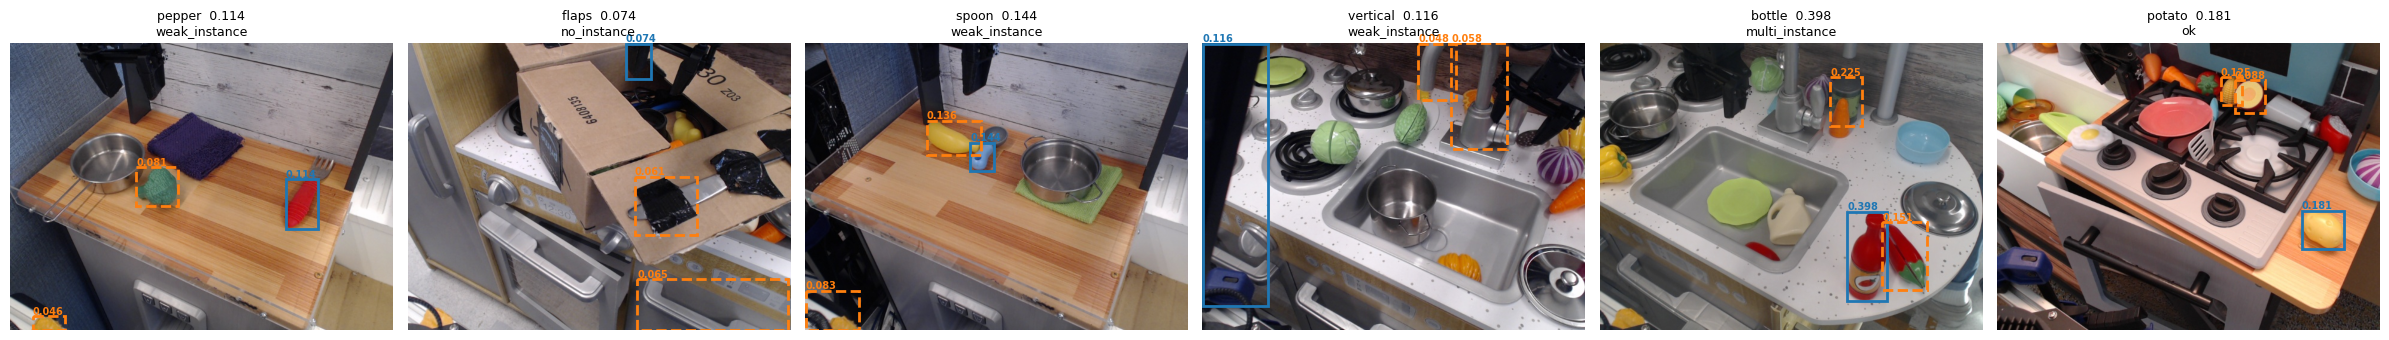

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

shown = [r for r in records if r['boxes']][:6]
if shown:
    fig, axes = plt.subplots(1, len(shown), figsize=(4 * len(shown), 4.4))
    axes = [axes] if len(shown) == 1 else list(axes)
    for ax, record in zip(axes, shown):
        ax.imshow(Image.open(os.path.join(CACHE_DIR, record['image_path'])))
        for rank, (box, score) in enumerate(zip(record['boxes'],
                                                record['scores'])):
            x0, y0, x1, y1 = box
            # The top box is the one a construction would cut; the rest are what
            # the gate reads as further instances.
            colour = 'tab:blue' if rank == 0 else 'tab:orange'
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                   edgecolor=colour, linewidth=2,
                                   linestyle='-' if rank == 0 else '--'))
            ax.text(x0, y0 - 3, f'{score:.3f}', color=colour, fontsize=7,
                    fontweight='bold')
        ax.set_title(f"{record['noun']}  {record['scores'][0]:.3f}"
                     f"\n{record['verdict']}", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No detections at all. The queried nouns, not the thresholds, are the '
          'problem. Check the noun list printed above against the frames.')

## 4. Build the constructed set

For each eligible frame the target noun is detected, and frames holding anything
other than exactly one confident instance are skipped: a second instance means
the scene is already a two-instance trial, and no instance means there is nothing
to duplicate. Every configuration the frame can support is then built.

An instance here is an object rather than a box. The detector emits a dense set of
candidate boxes and suppresses none of them, so one object returns a whole-object
box together with boxes on its parts and near-copies from neighbouring image
patches. Overlapping boxes are merged before the count, since counting the raw
boxes would rule almost every single-object frame a two-instance scene.

A configuration is skipped rather than approximated when it cannot be realised,
for example when the duplicate would leave the frame or land on the wrong side
of the start position. Every constructed scene is therefore one where the
intended arrangement was actually achieved, so the recorded geometry can be
trusted without further inspection. The rejection counts are printed so the
yield is visible rather than silent.

The duplicate is cut along the object's own outline, obtained by prompting a
segmentation model with the detected box. Cutting along the bounding box instead
transfers the table, the shadow, and any neighbouring object that falls inside
the rectangle, which is why a box cutout reads as a pasted rectangle rather than
as a second object. Scenes fall back to a box cutout when segmentation is
unavailable, and `by_cutout` reports how many did.

`SINGLE_HIGH` and `SINGLE_SECOND_MAX` are set from the diagnostic above rather
than left at their defaults. Raising `SINGLE_HIGH` buys trustworthy boxes at the
cost of frames; lowering it does the reverse. The gate that applies them is shared
with the diagnostic, so what was reported there is what is built here.

The run is target-driven and stops once every configuration has reached its goal,
which is the final target multiplied by `OVERBUILD` to leave room for the scenes
the screen will reject. Set `OVERBUILD` from the observed approval rate once a
first batch has been screened; before that, building roughly twice the target is
the reasonable opening position.

Every configuration a frame supports is built even after that cell is full, so
a frame's opposite and same-side scenes remain available as a pair, which is what
the frozen set is selected on.

Candidates are shuffled under `SEED` before `LIMIT` applies. Bridge episodes are
ordered by scene and task, so a prefix of the manifest would cover a handful of
domains rather than the pool. Set `LIMIT` to a small number for a trial run.

Safe to re-run: base frames already in the manifest are skipped and new scenes are
appended, so a session that ends early loses at most the current batch.

In [ ]:
INSTRUCTION_MODE = MODE_SYNTHESISED  # or MODE_INHERITED for verbatim wording
TARGETS = DEFAULT_TARGETS  # 300 opposite, 150 same-side left, 150 same-side right
OVERBUILD = 5.0         # build this multiple of the target to absorb rejections
LIMIT = None            # e.g. 25 for a trial run
SEED = 0                # fixes both the candidate order and the compositing
DETECT_GRIPPER = True   # fall back to the image centre when detection fails
SEGMENT = True          # cut along the object outline rather than its box

# Calibrated against the quantiles reported in section 3b.
GATE_SINGLE_HIGH = SINGLE_HIGH
GATE_SINGLE_SECOND_MAX = SINGLE_SECOND_MAX

summary = run_construction(
    CACHE_DIR, CONSTRUCTED_DIR,
    manifest_rows=manifest_rows,
    targets=TARGETS,
    overbuild=OVERBUILD,
    limit=LIMIT,
    seed=SEED,
    detect_gripper=DETECT_GRIPPER,
    segment=SEGMENT,
    instruction_mode=INSTRUCTION_MODE,
    single_high=GATE_SINGLE_HIGH,
    single_second_max=GATE_SINGLE_SECOND_MAX,
)
summary

[run_construction] 104 frames processed, built {'opposite': 608, 'same_side_left': 322, 'same_side_right': 360}
[run_construction] 238 frames processed, built {'opposite': 619, 'same_side_left': 325, 'same_side_right': 366}
[run_construction] 357 frames processed, built {'opposite': 628, 'same_side_left': 332, 'same_side_right': 370}
[run_construction] 431 frames processed, built {'opposite': 638, 'same_side_left': 338, 'same_side_right': 374}
[run_construction] 543 frames processed, built {'opposite': 648, 'same_side_left': 342, 'same_side_right': 380}
[run_construction] 651 frames processed, built {'opposite': 658, 'same_side_left': 345, 'same_side_right': 387}
[run_construction] 746 frames processed, built {'opposite': 668, 'same_side_left': 353, 'same_side_right': 390}
[run_construction] 891 frames processed, built {'opposite': 676, 'same_side_left': 359, 'same_side_right': 396}
[run_construction] 1006 frames processed, built {'opposite': 684, 'same_side_left': 364, 'same_side_righ

{'candidates': 14931,
 'processed': 3699,
 'skipped_existing': 328,
 'constructed': 647,
 'by_configuration': {'opposite': 900,
  'same_side_left': 486,
  'same_side_right': 531},
 'by_cutout': {'mask': 647},
 'rejected': {'no_instance': 658,
  'weak_instance': 399,
  'multi_instance': 1297,
  'no_surface': 0,
  'no_placement': 828,
  'missing_frame': 0},
 'goals': {'opposite': 900, 'same_side_left': 450, 'same_side_right': 450},
 'goals_met': True}

## 5. Inspect the recorded geometry

The measurement reads direction from the manifest, not from the picture, so the
manifest and the picture must agree. Each panel draws the recorded boxes onto the
constructed frame: the source instance, the pasted duplicate, and the start
position.

The boxes are drawn at their recorded coordinates rather than as markers at a
nominal height, because that is what makes a fault visible. A box that sits above
or beside the object it names means the cut was taken from the wrong pixels, and
the duplicate will then be a patch of background. Such a scene must be rebuilt,
not merely excluded, since the same fault affects every scene from that frame.

`cutout` reports whether the duplicate was cut along the object's outline
(`mask`) or along its bounding box (`box`). A box cutout carries the table and
any neighbouring object inside the rectangle, so it reads as a pasted rectangle
rather than as a second object.

1917 constructed scenes in the manifest


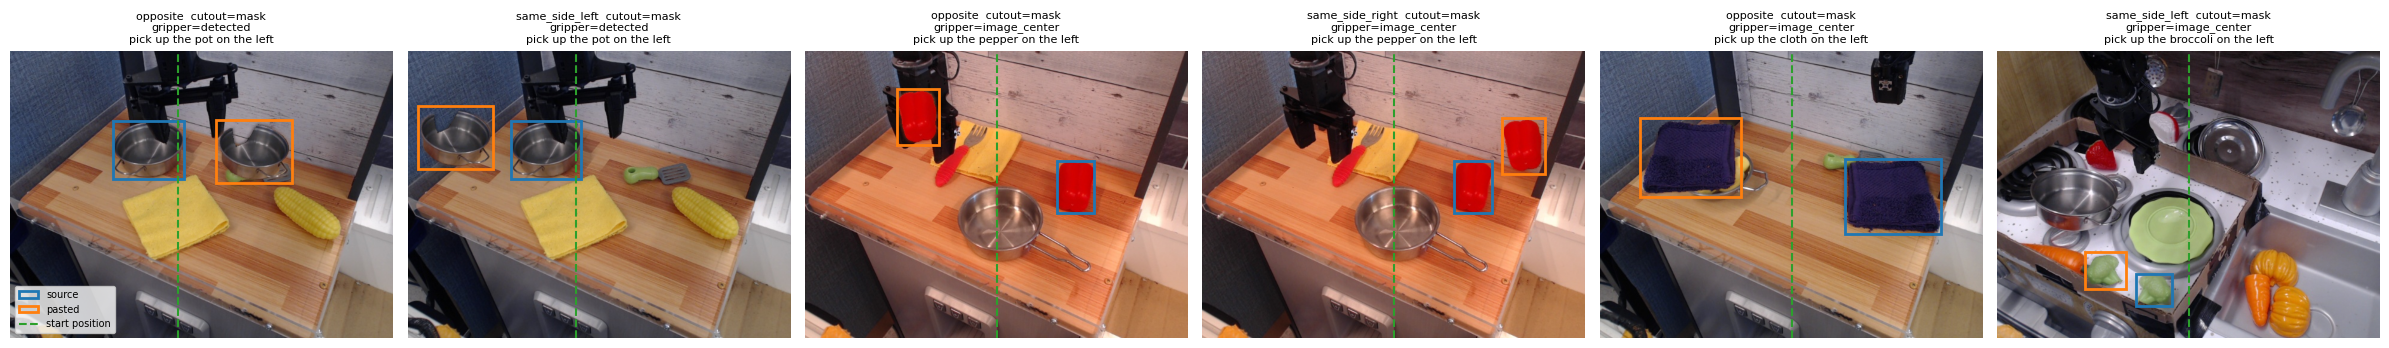

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

scenes = load_constructed_manifest(CONSTRUCTED_DIR)
print(f'{len(scenes)} constructed scenes in the manifest')


def draw_box(ax, spec, colour, label):
    """Draw a recorded 'x0,y0,x1,y1' box at its own coordinates."""
    if not spec:
        return
    x0, y0, x1, y1 = (float(v) for v in spec.split(','))
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                           edgecolor=colour, linewidth=2, label=label))


N_SHOW = 6
sample = scenes[:N_SHOW]
if sample:
    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4.6))
    axes = [axes] if len(sample) == 1 else list(axes)
    for ax, scene in zip(axes, sample):
        image = Image.open(os.path.join(CONSTRUCTED_DIR, scene['image_path']))
        ax.imshow(image)
        draw_box(ax, scene['source_box'], 'tab:blue', 'source')
        draw_box(ax, scene['paste_box'], 'tab:orange', 'pasted')
        ax.axvline(float(scene['x_gripper']), color='tab:green', linestyle='--',
                   linewidth=1.5, label='start position')
        ax.set_title(f"{scene['configuration']}  cutout={scene['cutout_mode']}"
                     f"\ngripper={scene['gripper_source']}"
                     f"\n{scene['instr_a']}", fontsize=8)
        ax.axis('off')
    axes[0].legend(loc='lower left', fontsize=7)
    plt.tight_layout()
    plt.show()

## 6. Yield and balance

The analysis compares configurations against each other, so a badly unbalanced
set would leave the decisive same-side comparison underpowered even when the
total looks healthy. The counts below are what determine whether the constructed
set can carry the primary analysis.

`gripper_source` records how the start position was obtained for each scene.
A high fallback rate weakens the same-side configurations specifically, because
those are defined relative to that position, and it should be reported alongside
the result.

In [ ]:
import pandas as pd

manifest = pd.DataFrame(scenes)
if len(manifest):
    for col in ('separation_px', 'offset_a_px', 'offset_b_px', 'source_score'):
        manifest[col] = manifest[col].astype(float)

    print('scenes per configuration:')
    print(manifest['configuration'].value_counts().to_string())
    print('\nspatial term:', dict(manifest['spatial_term'].value_counts()))
    print('gripper localisation:', dict(manifest['gripper_source'].value_counts()))
    print(f"\nbase frames used: {manifest['base_scene_id'].nunique()}")
    print(f"distinct target nouns: {manifest['noun'].nunique()}")
    print('\nseparation between instances (px):')
    print(manifest.groupby('configuration')['separation_px'].describe()[
        ['count', 'mean', 'min', 'max']].to_string())

    # A same-side scene must have both targets on one side of the start
    # position, and an opposite scene must straddle it. Verified against the
    # recorded numbers rather than assumed from the label.
    same_side = (manifest['offset_a_px'] * manifest['offset_b_px'] > 0)
    expected = manifest['configuration'] != 'opposite'
    print(f'\ngeometry consistent with the configuration label: '
          f'{int((same_side == expected).sum())}/{len(manifest)}')

scenes per configuration:
configuration
opposite           900
same_side_right    531
same_side_left     486

spatial term: {'left': np.int64(1917)}
gripper localisation: {'detected': np.int64(1175), 'image_center': np.int64(742)}

base frames used: 1537
distinct target nouns: 95

separation between instances (px):
                 count        mean        min         max
configuration                                            
opposite         900.0  258.178331  42.484741  520.851822
same_side_left   486.0  110.722234  33.093027  268.910074
same_side_right  531.0  110.073855  33.602124  247.964729

geometry consistent with the configuration label: 1915/1917


## 7. Approval screen

Every constructed scene is looked at once before it can enter the experiments, and
a scene that fails is excluded with its reason recorded.

This screens stimuli, it does not select results. It runs before any prediction
exists, it is blind to the model, and its criteria are fixed in advance. What it
removes are composites that failed as stimuli: if the pasted copy does not read as
a second object of the named kind, the instruction has no second referent and the
trial cannot measure grounding whatever the model does. Hand-picking scenes on the
property being measured is a different thing, and remains rejected.

Every criterion is decidable from the image and the instruction alone. Whether the
arrangement matches the one recorded, and whether the marked start position is
really the arm, are deliberately not criteria here: judging them means being shown
the pipeline's own answer, and a scene kept because it agreed with that answer
would make the recorded geometry unfalsifiable. Those two are measured instead in
section 10, on a random subsample labelled blind, where disagreement is reported
rather than removed.

Approve a scene when two instances of the named object are visible and the copy
reads as an object in the scene. Otherwise choose the reason:

| Button | Meaning |
| --- | --- |
| `ok` | two instances of the named object, the copy reads as an object |
| `no 2nd` | the copy does not read as a second object of that kind |
| `paste` | it reads as a patch: a visible seam, floating, or the wrong scale |
| `wrong obj` | neither object is the noun the instruction names |
| `other` | anything else, with a note |

Scenes are shown grouped by base frame, since a frame contributes to the set only
when both of its scenes pass. Decisions are keyed by `construct_id` in
`constructed_review.csv`, separate from the constructed manifest so that continuing
construction cannot overwrite them, and every page save rewrites that file, so a
session can be interrupted and resumed.

The screen conditions the estimate on stimulus quality: what is measured is
grounding given a well-posed and perceptible scene. Rejected scenes are kept in the
manifest, so a sample of them can be probed later as a check on what the screen
bought.

In [ ]:
# Read the manifest again, so screening reflects everything built to date whether
# or not construction ran in this session, then refresh the review file against it,
# keeping the decisions already recorded.
scenes = load_constructed_manifest(CONSTRUCTED_DIR)
review_rows = sync_review(scenes, CONSTRUCTED_DIR)
progress = approval_summary(review_rows, targets=TARGETS)
print(f"{progress['scenes']} scenes built, {progress['reviewed']} screened, "
      f"{progress['unlabelled']} still to see")
for configuration, entry in sorted(progress['by_configuration'].items()):
    print(f"  {configuration:16} approved {entry['approved']:4} "
          f"of target {entry.get('target', '-')!s:>4}  "
          f"(still needed {entry.get('still_needed', '-')})")

1917 scenes built, 880 screened, 1037 still to see
  opposite         approved  239 of target  300  (still needed 61)
  same_side_left   approved  114 of target  150  (still needed 36)
  same_side_right  approved   99 of target  150  (still needed 51)


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

PAGE = 6  # scenes per page; three base frames at a time

# The buttons carry no geometry, no configuration, and no detector score, so a
# judgement cannot be anchored on the pipeline's own answer.
CHOICES = {
    'skip': None,
    'ok': (DECISION_APPROVED, ''),
    'no 2nd': (DECISION_REJECTED, 'no_second_instance'),
    'paste': (DECISION_REJECTED, 'paste_implausible'),
    'wrong obj': (DECISION_REJECTED, 'object_wrong'),
    'other': (DECISION_REJECTED, 'other'),
}

# Names are prefixed because a second annotator screen further down this notebook
# shares the module namespace. Under plain names, whichever cell ran last rebinds
# the state and the button, so the save handler reads the other screen's state and
# records nothing while appearing to succeed.
screen_by_id = {s['construct_id']: s for s in scenes}
screen_state = {'controls': []}
header = widgets.Output()   # how much is left
status = widgets.Output()   # progress against the targets
# The page is a container whose children are replaced rather than an `Output` that
# is written into. Widget views nested inside an `Output` are not instantiated by
# the Colab widget manager, so displaying the page that way leaves the screen blank
# and raises nothing.
grid = widgets.VBox([])


# Scenes whose base frame yielded only one arrangement cannot enter the frozen
# set, since selection admits scenes in within-frame pairs, so screening them
# spends the scarcest resource in the pipeline on scenes that cannot be used.
screen_eligible = pair_eligible_ids(scenes)


def screen_pending():
    """Unscreened scenes that could enter the set, grouped by base frame.

    Grouped so a frame is judged together, and restricted to pair-eligible
    scenes. The restriction changes which scenes are offered, never how one is
    judged: the panel still carries no arrangement, geometry, or detector score.
    """
    rows = [r for r in review_rows
            if not r['decision'] and r['construct_id'] in screen_eligible]
    return sorted(rows, key=lambda r: (str(r['base_scene_id']),
                                       r['configuration']))


def screen_render():
    queue = screen_pending()
    with header:
        clear_output(wait=True)
        skipped = sum(1 for r in review_rows if not r['decision']
                      and r['construct_id'] not in screen_eligible)
        print(f'{len(queue)} scenes still to screen '
              f'({skipped} unscreened scenes cannot pair and are not offered)')
    page = queue[:PAGE]
    panels, controls = [], []
    for row in page:
        scene = screen_by_id.get(row['construct_id'])
        choice = widgets.ToggleButtons(options=list(CHOICES), value='skip',
                                       style={'button_width': '72px'})
        note = widgets.Text(placeholder='note', layout=widgets.Layout(width='260px'))
        controls.append((row, choice, note))
        if scene is None:
            panels.append(widgets.VBox([widgets.Label('image missing'), choice]))
            continue
        with open(os.path.join(CONSTRUCTED_DIR, scene['image_path']), 'rb') as f:
            data = f.read()
        panels.append(widgets.VBox([
            widgets.Image(value=data, format='png', width=300),
            widgets.HTML(f"<b>{row['instr_a']}</b>"),
            choice, note,
        ]))
    if not panels:
        grid.children = (widgets.HTML('<b>screening complete</b>'),)
        screen_state['controls'] = []
        return
    rows_of_three = [widgets.HBox(panels[i:i + 3])
                     for i in range(0, len(panels), 3)]
    grid.children = tuple(rows_of_three + [widgets.HBox([screen_save_button])])
    screen_state['controls'] = controls


def screen_save(_):
    for row, choice, note in screen_state.get('controls', []):
        decision = CHOICES[choice.value]
        if decision is None:
            continue
        verdict, reason = decision
        approve(review_rows, row['construct_id'], decision=verdict, reason=reason,
                notes=note.value)
    write_review(review_rows, CONSTRUCTED_DIR)
    done = approval_summary(review_rows, targets=TARGETS)
    with status:
        clear_output(wait=True)
        print(f"screened {done['reviewed']} of {done['scenes']}, "
              f"approved {done['approved']}")
        for configuration, entry in sorted(done['by_configuration'].items()):
            print(f"  {configuration:16} approved {entry['approved']:4} "
                  f"still needed {entry.get('still_needed', '-')}")
    screen_render()


screen_save_button = widgets.Button(description='Save page and next',
                                    button_style='primary')
screen_save_button.on_click(screen_save)
display(widgets.VBox([header, status, grid]))
screen_render()

## 8. What the screen removed

Reported as a funnel rather than a single pass rate, because the reasons point at
different faults and which one dominates decides what to change. A dominant
`no 2nd` says the composite is not perceived as two objects, which is the
pipeline's central claim failing; a dominant `paste` says the compositing needs
work on scale, seating, or colour; a dominant `wrong obj` says the noun written
into the instruction is not the object in the frame, which is an extraction fault
upstream.

Rates are given per configuration and never pooled. If the arrangements are
admitted at materially different rates then the arms of the decisive comparison
were screened to different standards, which is a threat to that comparison and has
to be reported with it. The rate per cutout mode is the direct test of whether box
fallbacks are usable at all.

In [ ]:
funnel = approval_summary(load_review(CONSTRUCTED_DIR), targets=TARGETS)
print(f"built {funnel['scenes']}  screened {funnel['reviewed']}  "
      f"approved {funnel['approved']}  rejected {funnel['rejected']}  "
      f"unseen {funnel['unlabelled']}")
print(f"approval rate: {funnel['approval_rate']:.1%}")

print('\nby configuration:')
for configuration, entry in sorted(funnel['by_configuration'].items()):
    print(f"  {configuration:16} screened {entry['reviewed']:4}  "
          f"approved {entry['approved']:4}  rate {entry['approval_rate']:.1%}")

print('\nrejections by reason:')
for reason, count in sorted(funnel['by_reject_reason'].items(),
                            key=lambda kv: -kv[1]):
    print(f"  {reason:20} {count}")

print('\napproval rate by cutout:')
for mode, entry in sorted(funnel['by_cutout'].items()):
    print(f"  {mode:6} n={entry['scenes']:4}  rate {entry['approval_rate']:.1%}")

built 1917  screened 1140  approved 573  rejected 567  unseen 777
approval rate: 50.3%

by configuration:
  opposite         screened  556  approved  305  rate 54.9%
  same_side_left   screened  296  approved  146  rate 49.3%
  same_side_right  screened  288  approved  122  rate 42.4%

rejections by reason:
  paste_implausible    528
  object_wrong         22
  no_second_instance   17

approval rate by cutout:
  mask   n=1917  rate 50.3%


## 8b. What the pool will yield

The freeze below fills its cells from base frames that carry both arrangements and
had both scenes approved, so the yield that matters is measured per frame rather
than per scene. Two rates compound to produce it: the share of frames whose
placements both fit, and the share of those pairs where neither scene is rejected.
A scene-level approval rate looks healthier than the set actually is, because
rejecting either member withdraws the frame.

Projecting from those measured rates gives the size of harvest, GPU pass, and
manual screen that filling the targets would take, which is the number to size a
harvest by rather than a guess. The screening figure counts pair-eligible scenes
only, since the rest cannot enter the set however they are judged.

Where a rate is zero or not yet measurable the requirement is reported as unknown
rather than as a finite number, so an unscreened set cannot appear to imply a
precise amount of work.

In [ ]:
import math

# The candidate pool construction draws from, which is the denominator a harvest
# is sized against: cached construction frames that pass the instruction and
# category filters, not the whole cache.
candidates = select_base_scenes(manifest_rows, instruction_mode=INSTRUCTION_MODE)
projection = project_yield(scenes, review_rows, targets=TARGETS,
                           candidates_processed=len(candidates))

print(f"candidate frames in the cache : {len(candidates)} of "
      f"{len(construction_pool)} in the construction role")
print(f"frames that yielded a scene   : {projection['base_frames']}")
print(f"  carrying both arrangements  : {projection['paired_frames']} "
      f"({projection['pair_rate']:.1%} of them)")
print(f"pairs fully screened          : {projection['decided_pairs']}")
print(f"  both scenes approved        : {projection['approved_pairs']} "
      f"({projection['joint_approval_rate']:.1%})")
print(f"  by same-side arrangement    : {projection['approved_by_side']}")
print(f"\npaired frames needed          : {projection['paired_frames_needed']}")
print(f"still short                   : {projection['paired_frames_short']}")

if projection['paired_frames_short'] == 0:
    print('\nevery cell is covered; freeze below')
elif projection['pairs_to_build'] is None:
    print('\nToo little screened to project a requirement: no pair has both scenes '
          'approved yet, so the joint rate the projection divides by is zero. '
          'Screen further and re-run this cell.')
else:
    # Candidate frames are what construction consumes, but the harvest is measured
    # in cached construction frames, so the requirement is carried back through
    # the share of the cache that qualifies as a candidate.
    qualifying = len(candidates) / max(len(construction_pool), 1)
    harvest = math.ceil(projection['candidates_to_process'] / qualifying)
    print('\nat the measured rates, filling the targets takes:')
    print(f"  pairs to build              : {projection['pairs_to_build']}")
    print(f"  scenes to screen            : {projection['scenes_to_screen']}"
          '  (pair-eligible only)')
    print(f"  candidate frames to process : {projection['candidates_to_process']}")
    print(f"  construction frames to cache: {harvest} "
          f"({harvest / max(len(construction_pool), 1):.1f} times the current cache)")
    print('\nRaise the construction target in Notebook 02 and continue the harvest, '
          'then re-run section 4 to build from the new frames. Construction and '
          'the harvest both resume, so neither repeats work already done.')

candidate frames in the cache : 14931 of 16000 in the construction role
frames that yielded a scene   : 1537
  carrying both arrangements  : 380 (24.7% of them)
pairs fully screened          : 380
  both scenes approved        : 120 (31.6%)
  by same-side arrangement    : {'same_side_left': 64, 'same_side_right': 56}

paired frames needed          : 300
still short                   : 180

at the measured rates, filling the targets takes:
  pairs to build              : 570
  scenes to screen            : 1140  (pair-eligible only)
  candidate frames to process : 22397
  construction frames to cache: 24001 (1.5 times the current cache)

Raise the construction target in Notebook 02 and continue the harvest, then re-run section 4 to build from the new frames. Construction and the harvest both resume, so neither repeats work already done.


## 9. Freeze the experimental set

Selects the screened scenes into a fixed list of 300 opposite, 150 same-side left,
and 150 same-side right, written to `evaluation_set.csv`. Every later stage reads
that file. Re-deriving the selection wherever it is needed would let the set drift
as screening continued, and the probe, the analysis, and the figures would then
describe different scenes.

The same-side cells are filled first, because they bind: a base frame supports the
same-side arrangement only on the side its object already occupies, so the scarcer
side decides how many frames are needed. The opposite cell is then taken from those
same frames, which makes the same-side against opposite contrast a within-frame
comparison holding background, object, cutout, and instruction fixed. Scene
identity therefore cannot explain a difference between the arrangements, which is
the whole point of the contrast.

Frames are drawn at random under `SELECTION_SEED` from those whose scenes passed,
so the rule is mechanical and the set reproduces. A cell that cannot be filled is
reported as a shortfall rather than padded from unpaired scenes: substituting an
unpaired scene would silently change what the comparison controls for. A shortfall
means returning to section 4 and building more, then screening the additions.

In [ ]:
SELECTION_SEED = 0

FREEZE_TARGETS = {
    'opposite': 120,
    'same_side_left': 64,
    'same_side_right': 56,
}

selection = select_evaluation_set(scenes, approved_ids(load_review(CONSTRUCTED_DIR)),
                                  targets=FREEZE_TARGETS, seed=SELECTION_SEED)
print(f"approved scenes available: {selection['approved_scenes']}")
print(f"paired base frames used  : {selection['paired_base_frames']}")
print('counts:', selection['counts'])
if selection['complete']:
    write_evaluation_set(selection['rows'], CONSTRUCTED_DIR)
    frozen = evaluation_scenes(CONSTRUCTED_DIR, scenes)
    print(f'\nfrozen set: {len(frozen)} scenes')
    print('by configuration:', dict(Counter(r['configuration'] for r in frozen)))
    print('by cutout:', dict(Counter(r['cutout_mode'] for r in frozen)))
    print('gripper localisation:', dict(Counter(r['gripper_source'] for r in frozen)))
else:
    print('\nshortfall, nothing frozen:', selection['shortfall'])
    print('build more scenes in section 4 and screen them before freezing')

approved scenes available: 573
paired base frames used  : 120
counts: {'same_side_left': 64, 'same_side_right': 56, 'opposite': 120}
[write_evaluation_set] froze 240 scenes -> /content/drive/MyDrive/openvla_cache/v2/constructed/evaluation_set.csv

frozen set: 240 scenes
by configuration: {'same_side_left': 64, 'same_side_right': 56, 'opposite': 120}
by cutout: {'mask': 240}
gripper localisation: {'image_center': 106, 'detected': 134}


## 10. Geometry agreement on a blind subsample

The measurement reads direction from the recorded geometry, so that geometry is
the central assumption of the constructed set, and it rests on an open-vocabulary
detector never evaluated on this data. A hand-labelled sample gives it a
reportable agreement number instead of an assumption.

This is what carries the two judgements the approval screen deliberately excludes:
whether the arrangement is the one recorded, and whether the marked start position
is really the arm. Here the annotator states what the image shows without being
shown the pipeline's answer, and disagreement is reported rather than removed, so
the geometry remains falsifiable. Had those been screening criteria, scenes would
have been kept for agreeing with the claim they are supposed to test.

The sample is drawn at random and stratified by configuration, never chosen. A
sample picked by eye would be selected on the same appearance the labelling then
judges, and its agreement would measure nothing. Stratifying keeps the same-side
arrangements represented, since they are fewer and carry the decisive comparison.

`agreement_pool` decides which scenes it is drawn from: the frozen set once that
exists, and the approved scenes before it. Rejected and unscreened scenes are
excluded because a rejection cites faults, such as an implausible paste, that also
make the arrangement harder to read, so an agreement number measured over them
would understate the geometry of the set the probe runs on. Conditioning on
approval is not circular here, since the screen decides without the recorded
arrangement in view.

Scenes already labelled are kept and topped up around rather than redrawn, so the
labelling survives the pool growing as screening continues. The retained scenes
were drawn at random themselves, and restricting a random sample to a subset
defined without reference to the draw leaves a random sample of that subset.

In [ ]:
from compose_scenes import (agreement_pool, draw_validation_sample,
                            write_validation_sample, load_validation_sample,
                            validation_agreement)

SAMPLE_N = 50
SAMPLE_SEED = 0

# The pool is resolved by the module, which returns the frozen set when it exists
# and the approved scenes otherwise, never the whole build.
pool, pool_source = agreement_pool(CONSTRUCTED_DIR, scenes)

# Labels already collected are retained where the scene is still in the pool, so
# labelling is not repeated every time the pool grows.
prior = (load_validation_sample(CONSTRUCTED_DIR)
         if os.path.isfile(os.path.join(CONSTRUCTED_DIR, 'validation_sample.csv'))
         else [])
labelled = {r['construct_id'] for r in prior if r['human_configuration']}

if not pool:
    print('no scenes are eligible yet: approve scenes in section 7 first')
else:
    sample = draw_validation_sample(pool, n=SAMPLE_N, seed=SAMPLE_SEED,
                                    retain=labelled, pool=pool_source)
    write_validation_sample(sample, CONSTRUCTED_DIR)
    kept = sum(1 for r in sample if r['construct_id'] in labelled)
    print(f'pool: {pool_source}, {len(pool)} scenes eligible')
    print(f'{len(sample)} scenes drawn for labelling '
          f'({kept} already labelled and retained)')
    dropped = len(labelled) - kept
    if dropped:
        print(f'{dropped} earlier labels discarded: those scenes are not in the pool')
    print('by configuration:', dict(Counter(r['configuration'] for r in sample)))
    print('by cutout:', dict(Counter(r['auto_cutout_mode'] for r in sample)))

[write_validation_sample] 50 scenes -> /content/drive/MyDrive/openvla_cache/v2/constructed/validation_sample.csv
pool: frozen, 240 scenes eligible
50 scenes drawn for labelling (19 already labelled and retained)
31 earlier labels discarded: those scenes are not in the pool
by configuration: {'opposite': 17, 'same_side_left': 16, 'same_side_right': 17}
by cutout: {'mask': 50}


### Annotator

Each panel shows one constructed scene with no markers, so the arrangement is
judged from the image rather than read off the pipeline's own answer. Record
what the image shows: how the two instances sit relative to the robot's start
position, whether two instances of the named object are visible at all, whether
the start position is where the arm actually is, and whether the duplicate reads
as a real object rather than a pasted rectangle.

Each save writes the whole sample file and advances, so a session can be
interrupted and resumed.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Prefixed for the same reason as the approval screen above: the two screens live in
# one namespace, and plain names let the later cell detach the earlier screen's
# controls from its handlers.
sample_rows = load_validation_sample(CONSTRUCTED_DIR)
sample_by_id = {s['construct_id']: s for s in scenes}
sample_queue = [r for r in sample_rows if not r['human_configuration']]
print(f'{len(sample_queue)} unlabelled of {len(sample_rows)}')

sample_state = {'i': 0}
out = widgets.Output()

configuration = widgets.ToggleButtons(
    options=['opposite', 'same_side_left', 'same_side_right', 'unclear'],
    description='Arrangement:', style={'description_width': 'initial'})
two_instances = widgets.ToggleButtons(
    options=['yes', 'no'], description='Two instances visible:',
    style={'description_width': 'initial'})
gripper_ok = widgets.ToggleButtons(
    options=['yes', 'no'], description='Start position on the arm:',
    style={'description_width': 'initial'})
paste_ok = widgets.ToggleButtons(
    options=['yes', 'no'], description='Duplicate looks real:',
    style={'description_width': 'initial'})
notes = widgets.Text(description='Notes:', layout=widgets.Layout(width='60%'))
sample_save_button = widgets.Button(description='Save and next',
                                   button_style='primary')
sample_skip_button = widgets.Button(description='Skip')


def sample_show():
    with out:
        clear_output(wait=True)
        if sample_state['i'] >= len(sample_queue):
            print('queue complete')
            return
        row = sample_queue[sample_state['i']]
        scene = sample_by_id.get(row['construct_id'])
        print(f"[{sample_state['i'] + 1}/{len(sample_queue)}] {row['construct_id']}")
        print('instruction A:', row['instr_a'])
        if scene is None:
            print('image missing from the manifest')
            return
        image = Image.open(os.path.join(CONSTRUCTED_DIR, scene['image_path']))
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        ax.imshow(image)
        ax.axis('off')
        plt.show()


def sample_save(_):
    row = sample_queue[sample_state['i']]
    row['human_configuration'] = configuration.value
    row['human_two_instances'] = two_instances.value
    row['human_gripper_ok'] = gripper_ok.value
    row['human_paste_plausible'] = paste_ok.value
    row['notes'] = notes.value
    write_validation_sample(sample_rows, CONSTRUCTED_DIR)
    notes.value = ''
    sample_state['i'] += 1
    sample_show()


def sample_skip(_):
    sample_state['i'] += 1
    sample_show()


sample_save_button.on_click(sample_save)
sample_skip_button.on_click(sample_skip)
display(widgets.VBox([out, configuration, two_instances, gripper_ok, paste_ok,
                      notes, widgets.HBox([sample_save_button,
                                           sample_skip_button])]))
sample_show()

31 unlabelled of 50


### Agreement

The number reported with the constructed set. Configuration agreement is what
the geometry claim rests on. Gripper agreement bears mainly on the same-side
configurations, since those are defined relative to the start position, so a low
value weakens the decisive comparison specifically rather than the whole set.

A low paste-plausibility rate points the same way as a failed manipulation check
in Notebook 06. It is reported per cutout mode, because an outline cutout and a
bounding-box cutout are different stimuli and the box is expected to look worse:
pooling them would average away the distinction that decides whether any box
fallbacks are usable. If outline cutouts also read poorly, the remaining levers
are matching the duplicate's scale and vertical position to the table perspective
and harmonising its colour to the local lighting.

In [ ]:
sample_labelled = load_validation_sample(CONSTRUCTED_DIR)
agreement = validation_agreement(sample_labelled)
# Reported with the pool, since an agreement number is only interpretable against
# the set it was measured on.
print('pool:', dict(Counter(r['pool'] or 'unrecorded' for r in sample_labelled)))
print(f"labelled {agreement['labelled']} of {agreement['drawn']} drawn")
print(f"configuration agreement : {agreement['configuration_agreement']:.1%}")
print(f"two instances visible   : {agreement['two_instances_rate']:.1%}")
print(f"start position correct  : {agreement['gripper_agreement']:.1%}")
print(f"duplicate looks real    : {agreement['paste_plausible_rate']:.1%}")
print('\nby recorded configuration:')
for name, entry in sorted(agreement['by_configuration'].items()):
    print(f"  {name:16} n={entry['n']:3}  agreement={entry['agreement']:.1%}")
print('\nduplicate looks real, by cutout:')
for name, entry in sorted(agreement['by_cutout'].items()):
    print(f"  {name:6} n={entry['n']:3}  "
          f"plausible={entry['paste_plausible_rate']:.1%}")

# Feasibility review belongs to the unaltered validation frames, where the implied
# placement may be impossible. A constructed trial chooses its arrangement, so
# feasibility holds by construction and the screen in section 7 is what stands in
# its place here.
validation_reviewed = [r for r in manifest_rows
                       if r.get('split') != SPLIT_CONSTRUCTION
                       and r.get('feasible_both', 'unreviewed') != 'unreviewed']
print(f'\nfeasibility labels on the validation frames (Notebook 04): '
      f'{len(validation_reviewed)}')

pool: {'frozen': 50}
labelled 50 of 50 drawn
configuration agreement : 86.0%
two instances visible   : 100.0%
start position correct  : 100.0%
duplicate looks real    : 88.0%

by recorded configuration:
  opposite         n= 17  agreement=94.1%
  same_side_left   n= 16  agreement=75.0%
  same_side_right  n= 17  agreement=88.2%

duplicate looks real, by cutout:
  mask   n= 50  plausible=88.0%

feasibility labels on the validation frames (Notebook 04): 4
